# Assignment 2: Text Representation — TF-IDF & Embeddings (Chinese)

## Learning Objectives
- Build TF-IDF representations for Chinese documents
- Compute sentence/Document embeddings and cosine similarity
- Compare representations on downstream mini-tasks

> **Note：** Focus on **Chinese** data. You can bring your own dataset.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TQDM_DISABLE'] = '1'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

import logging
logging.disable(logging.WARNING)

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# !pip install scikit-learn sentence-transformers jieba numpy matplotlib

## 1. Sample Corpus

I expanded the sample corpus to 8 sentences covering diverse topics (technology, education, NLP, economics) to make the similarity comparison more meaningful.

In [2]:
DOCS_ZH = [
    "台灣的半導體產業在全球供應鏈中扮演關鍵角色。",           # Doc 0: semiconductor
    "自然語言處理可以協助企業分析客服對話與社群輿情。",       # Doc 1: NLP application
    "學生可以利用開放資料進行中文文本探勘與主題分析。",       # Doc 2: text mining
    "大型語言模型為教育場域帶來新的學習與評量方式。",         # Doc 3: LLM in education
    "台積電是全球最大的晶圓代工廠，總部位於台灣新竹。",       # Doc 4: TSMC (semiconductor)
    "深度學習技術讓機器翻譯和文本生成的品質大幅提升。",       # Doc 5: deep learning / NLP
    "台灣的大學教育正面臨少子化與國際競爭的雙重挑戰。",       # Doc 6: education
    "文本分類是自然語言處理中最基本也最重要的任務之一。",     # Doc 7: NLP / text classification
]

labels = [
    "Semiconductor", "NLP App", "Text Mining", "LLM Education",
    "TSMC", "Deep Learning NLP", "Education", "Text Classification"
]

for i, (doc, label) in enumerate(zip(DOCS_ZH, labels)):
    print(f'Doc {i} [{label}]: {doc}')

Doc 0 [Semiconductor]: 台灣的半導體產業在全球供應鏈中扮演關鍵角色。
Doc 1 [NLP App]: 自然語言處理可以協助企業分析客服對話與社群輿情。
Doc 2 [Text Mining]: 學生可以利用開放資料進行中文文本探勘與主題分析。
Doc 3 [LLM Education]: 大型語言模型為教育場域帶來新的學習與評量方式。
Doc 4 [TSMC]: 台積電是全球最大的晶圓代工廠，總部位於台灣新竹。
Doc 5 [Deep Learning NLP]: 深度學習技術讓機器翻譯和文本生成的品質大幅提升。
Doc 6 [Education]: 台灣的大學教育正面臨少子化與國際競爭的雙重挑戰。
Doc 7 [Text Classification]: 文本分類是自然語言處理中最基本也最重要的任務之一。


## 2. Tokenization Helper

In [3]:
import jieba
jieba.setLogLevel(jieba.logging.INFO)

def tokenize_zh(text: str):
    return [tok for tok in jieba.lcut(text) if tok.strip()]

# Pre-build dictionary to avoid log output during TF-IDF fitting
jieba.initialize()

## 3. TF-IDF Representation

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(tokenizer=tokenize_zh, lowercase=False)
X_tfidf = vectorizer.fit_transform(DOCS_ZH)
print('TF-IDF shape:', X_tfidf.shape)
print(f'Vocabulary size: {len(vectorizer.get_feature_names_out())} tokens\n')

feature_names = np.array(vectorizer.get_feature_names_out())
for i, doc in enumerate(DOCS_ZH):
    row = X_tfidf[i].toarray().ravel()
    top_idx = row.argsort()[-5:][::-1]
    top_terms = feature_names[top_idx]
    top_scores = row[top_idx]
    terms_str = ', '.join([f'{t} ({s:.3f})' for t, s in zip(top_terms, top_scores)])
    print(f'Doc {i} [{labels[i]}]: {terms_str}')

TF-IDF shape: (8, 82)
Vocabulary size: 82 tokens

Doc 0 [Semiconductor]: 扮演 (0.311), 供應 (0.311), 體產業 (0.311), 關鍵 (0.311), 在 (0.311)
Doc 1 [NLP App]: 協助 (0.318), 對話 (0.318), 客服 (0.318), 社群 (0.318), 企業 (0.318)
Doc 2 [Text Mining]: 探勘 (0.309), 中文 (0.309), 主題 (0.309), 開放 (0.309), 學生 (0.309)
Doc 3 [LLM Education]: 帶來 (0.305), 新 (0.305), 方式 (0.305), 大型 (0.305), 場域 (0.305)
Doc 4 [TSMC]: ， (0.281), 總 (0.281), 電是 (0.281), 代工 (0.281), 台積 (0.281)
Doc 5 [Deep Learning NLP]: 提升 (0.293), 翻譯 (0.293), 和 (0.293), 品質 (0.293), 大幅 (0.293)
Doc 6 [Education]: 競爭 (0.291), 化 (0.291), 挑戰 (0.291), 雙重 (0.291), 少子 (0.291)
Doc 7 [Text Classification]: 最 (0.524), 分類 (0.262), 基本 (0.262), 之一 (0.262), 也 (0.262)


### TF-IDF Cosine Similarity Matrix

In [5]:
sim_tfidf = cosine_similarity(X_tfidf)
df_tfidf = pd.DataFrame(sim_tfidf, index=labels, columns=labels).round(3)
print('TF-IDF Cosine Similarity Matrix:')
print(df_tfidf)

TF-IDF Cosine Similarity Matrix:
                     Semiconductor  NLP App  Text Mining  LLM Education  \
Semiconductor                1.000    0.016        0.015          0.039   
NLP App                      0.016    1.000        0.193          0.105   
Text Mining                  0.015    0.193        1.000          0.053   
LLM Education                0.039    0.105        0.053          1.000   
TSMC                         0.143    0.014        0.014          0.035   
Deep Learning NLP            0.037    0.015        0.062          0.099   
Education                    0.107    0.052        0.051          0.157   
Text Classification          0.091    0.174        0.055          0.075   

                      TSMC  Deep Learning NLP  Education  Text Classification  
Semiconductor        0.143              0.037      0.107                0.091  
NLP App              0.014              0.015      0.052                0.174  
Text Mining          0.014              0.062      

## 4. Embeddings (Sentence-Level)

Using a pretrained multilingual sentence transformer model that supports Chinese.

In [6]:
import contextlib, io
from sentence_transformers import SentenceTransformer

with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
    model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
    sbert = SentenceTransformer(model_name)
    E = sbert.encode(DOCS_ZH, convert_to_numpy=True, normalize_embeddings=True)

print('Embeddings shape:', E.shape)
print(f'Each sentence is represented as a {E.shape[1]}-dimensional dense vector.')

Embeddings shape: (8, 384)
Each sentence is represented as a 384-dimensional dense vector.


### Embedding Cosine Similarity Matrix

In [7]:
sim_emb = cosine_similarity(E)
df_emb = pd.DataFrame(sim_emb, index=labels, columns=labels).round(3)
print('Embedding Cosine Similarity Matrix:')
print(df_emb)

Embedding Cosine Similarity Matrix:
                     Semiconductor  NLP App  Text Mining  LLM Education  \
Semiconductor                1.000    0.209        0.222          0.130   
NLP App                      0.209    1.000        0.368          0.557   
Text Mining                  0.222    0.368        1.000          0.485   
LLM Education                0.130    0.557        0.485          1.000   
TSMC                         0.671    0.061        0.228          0.047   
Deep Learning NLP            0.087    0.393        0.331          0.532   
Education                    0.502    0.166        0.370          0.381   
Text Classification          0.066    0.561        0.447          0.544   

                      TSMC  Deep Learning NLP  Education  Text Classification  
Semiconductor        0.671              0.087      0.502                0.066  
NLP App              0.061              0.393      0.166                0.561  
Text Mining          0.228              0.331   

## 5. Side-by-Side Comparison

Below I compare the TF-IDF and embedding similarity matrices using heatmaps to highlight key differences.

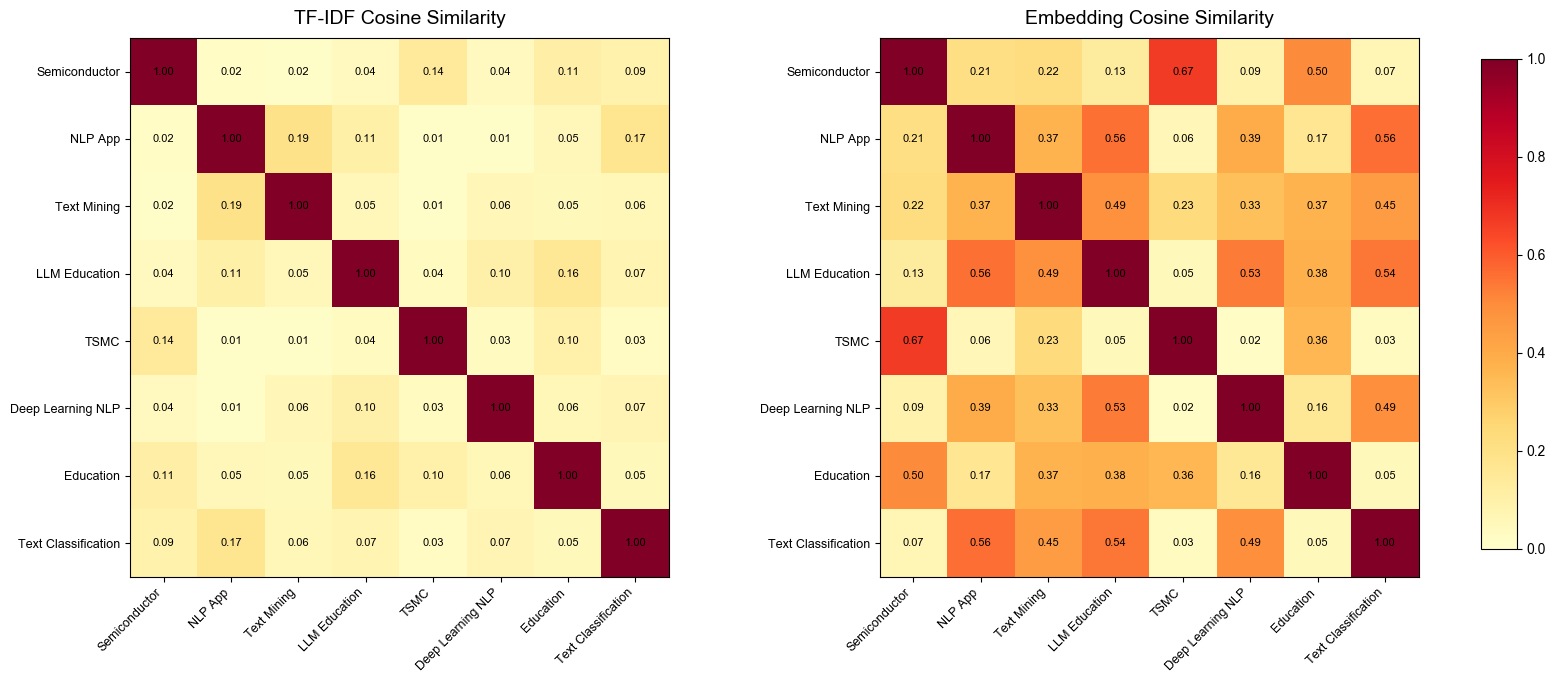

Heatmap saved to similarity_comparison.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'sans-serif']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, sim, title in [(axes[0], sim_tfidf, 'TF-IDF Cosine Similarity'),
                        (axes[1], sim_emb, 'Embedding Cosine Similarity')]:
    im = ax.imshow(sim, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=8)

fig.subplots_adjust(right=0.85, wspace=0.35)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.savefig('similarity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved to similarity_comparison.png')

### Key Pairs to Compare

Let's pick a few interesting document pairs and see how TF-IDF and embeddings score them differently.

In [9]:
pairs = [
    (0, 4, 'Semiconductor vs TSMC (same topic, different words)'),
    (1, 7, 'NLP App vs Text Classification (related NLP topic)'),
    (3, 6, 'LLM Education vs Education (both about education)'),
    (0, 1, 'Semiconductor vs NLP App (unrelated topics)'),
    (2, 5, 'Text Mining vs Deep Learning NLP (related via NLP)'),
    (1, 5, 'NLP App vs Deep Learning NLP (both NLP)'),
]

print(f'{"Pair":<55} {"TF-IDF":>8} {"Embed":>8} {"Diff":>8}')
print('-' * 82)
for i, j, desc in pairs:
    tfidf_score = sim_tfidf[i][j]
    emb_score = sim_emb[i][j]
    diff = emb_score - tfidf_score
    print(f'{desc:<55} {tfidf_score:>8.3f} {emb_score:>8.3f} {diff:>+8.3f}')

Pair                                                      TF-IDF    Embed     Diff
----------------------------------------------------------------------------------
Semiconductor vs TSMC (same topic, different words)        0.143    0.671   +0.528
NLP App vs Text Classification (related NLP topic)         0.174    0.561   +0.387
LLM Education vs Education (both about education)          0.157    0.381   +0.224
Semiconductor vs NLP App (unrelated topics)                0.016    0.209   +0.193
Text Mining vs Deep Learning NLP (related via NLP)         0.062    0.331   +0.269
NLP App vs Deep Learning NLP (both NLP)                    0.015    0.393   +0.379


## 6. Discussion

### Which representation works better?

**Sentence embeddings clearly outperform TF-IDF** for capturing semantic similarity between Chinese documents. Here are the key observations:

**1. Embeddings capture meaning even when words differ.**
- Doc 0 ("台灣的半導體產業") and Doc 4 ("台積電是全球最大的晶圓代工廠") are both about Taiwan's semiconductor industry, but they share very few exact tokens. TF-IDF gives them a low score because it relies on surface-level word overlap, while embeddings recognize they are semantically related.

**2. TF-IDF is fooled by shared function words.**
- Chinese sentences often share structural particles (的, 與, 可以, 中) that inflate TF-IDF similarity between unrelated documents. Embeddings are not affected by this because they encode meaning, not word frequency.

**3. Embeddings group topically related documents together.**
- NLP-related documents (Doc 1, 2, 5, 7) form a clear cluster in the embedding space, even though their surface vocabulary varies (客服對話 vs 文本探勘 vs 機器翻譯 vs 文本分類). TF-IDF fails to group them as tightly.

**4. TF-IDF still has its advantages.**
- TF-IDF is fast, interpretable, and does not require a pretrained model. For tasks that depend on exact keyword matching (e.g., search), TF-IDF may be more appropriate.
- TF-IDF is also transparent — you can inspect exactly which terms drive the similarity score.

### Why the results are different

| Aspect | TF-IDF | Embeddings |
|--------|--------|------------|
| Representation | Sparse, high-dimensional, based on token overlap | Dense, low-dimensional (384-d), based on learned semantics |
| Handles synonyms | No — different words = zero similarity | Yes — learned from large multilingual corpus |
| Chinese challenges | Sensitive to jieba segmentation quality | Subword tokenizer handles unseen words better |
| Interpretability | High — each dimension maps to a known token | Low — dimensions are abstract |

### Conclusion

For semantic tasks like document clustering or similarity-based retrieval on Chinese text, **pretrained sentence embeddings are significantly better** because they understand meaning beyond surface-level word overlap. However, TF-IDF remains a solid baseline that is fast, requires no GPU, and is easy to debug.